<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `DecodingExample.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: Workflow, model fitting, and decoded-stimulus figures now follow the MATLAB helpfile closely; exact traces still depend on stochastic simulation draws and Python plotting defaults.


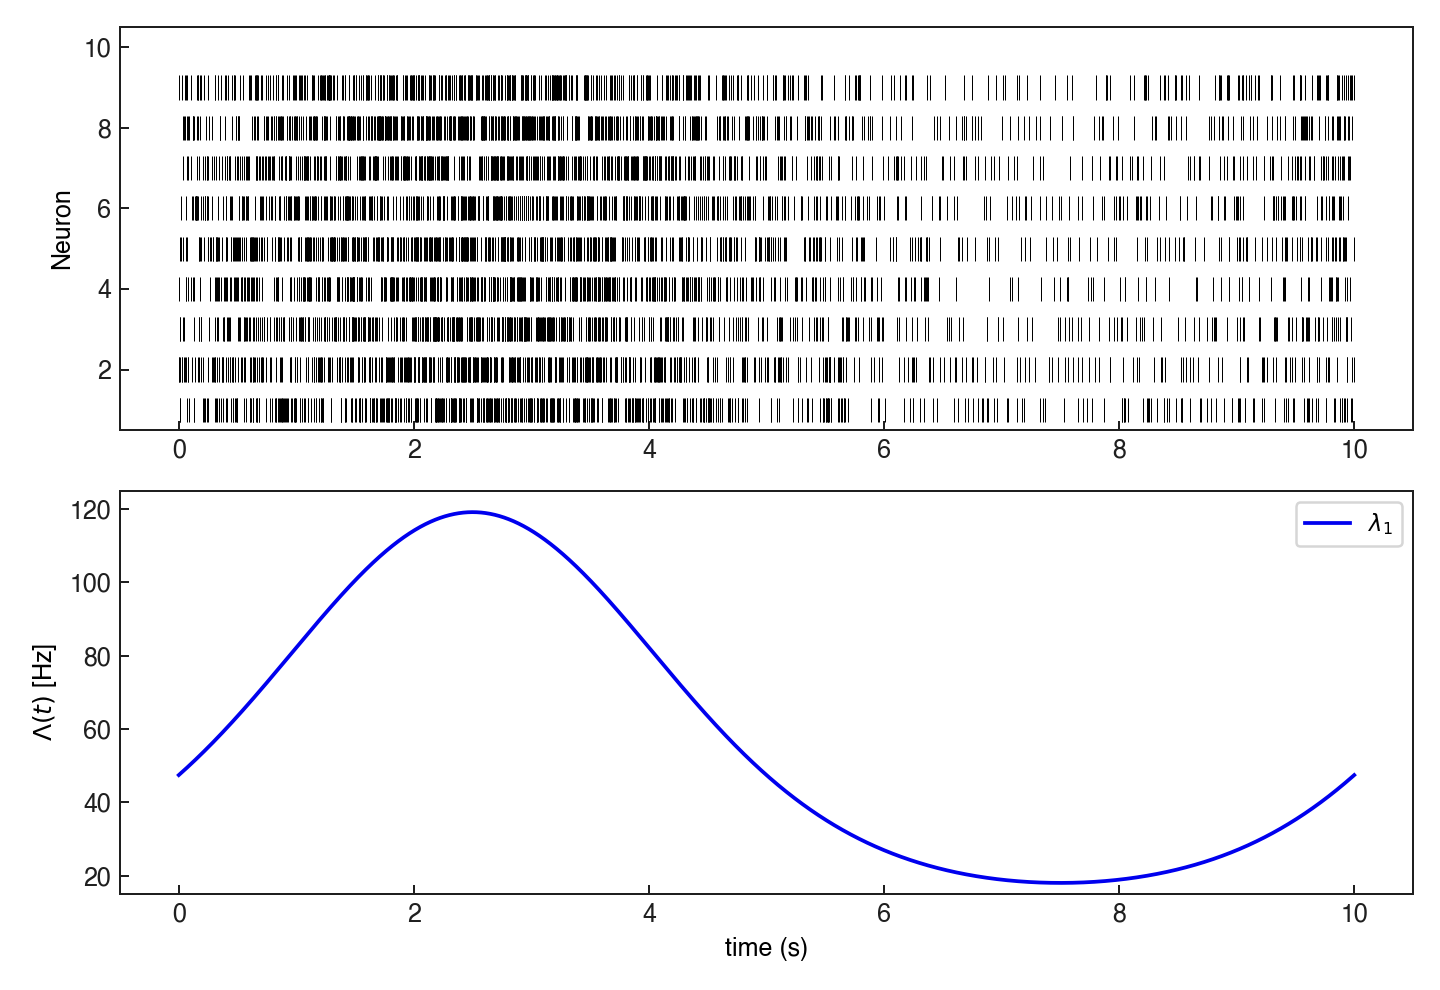

In [ ]:
# nSTAT-python notebook example: DecodingExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import (
    Analysis,
    CIF,
    ConfigColl,
    CovColl,
    Covariate,
    DecodingAlgorithms,
    FitResSummary,
    Trial,
    TrialConfig,
)
from nstat.notebook_figures import FigureTracker, matlab_raster

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="DecodingExample", output_root=OUTPUT_ROOT, expected_count=5)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_raster(ax, spike_coll):
    # MATLAB raster uses thin, short tick segments so individual spikes
    # remain resolvable across the 10-cell stack (consensus polish).
    # Use the centralized matlab_raster helper for MATLAB-faithful styling.
    for row in range(spike_coll.numSpikeTrains):
        train = spike_coll.getNST(row)
        spikes = np.asarray(train.getSpikeTimes(), dtype=float).reshape(-1)
        matlab_raster(ax, spikes, row=float(row), half_height=0.3, linewidth=0.4)
    ax.set_ylabel("Neuron")
    ax.set_ylim(0.5, spike_coll.numSpikeTrains + 0.5)


def _plot_decoded_ci(ax, time, decoded, cov, stim, title):
    center = np.asarray(decoded, dtype=float).reshape(-1)
    variance = np.asarray(cov, dtype=float).reshape(-1)
    sigma = np.sqrt(np.maximum(variance, 0.0))
    z_val = 3.0
    # MATLAB ciLower/ciUpper use min/max envelope construction.  For
    # non-negative sigma this collapses to center +/- z*sigma, but we
    # preserve the explicit min/max form to match the MATLAB code path.
    band_low = center - z_val * sigma
    band_high = center + z_val * sigma
    lower = np.minimum(band_low, band_high)
    upper = np.maximum(band_low, band_high)
    # MATLAB-style lime-green CI bands to match DecodingExample reference figure
    band_color = "#00FF00"
    ax.plot(time[: center.size], center, "b", linewidth=1.5, label=r"$x_{k|k}(t)$")
    ax.plot(time[: center.size], lower, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)-3\sigma_{kk}$")
    ax.plot(time[: center.size], upper, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)+3\sigma_{kk}$")
    ax.plot(time[: center.size], np.asarray(stim).reshape(-1)[: center.size], "k", linewidth=1.5, label=r"$x(t)$")
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    # MATLAB uses a plain "Stimulus" ylabel with default axis ticks and no
    # gridlines — minimal axis treatment, no dense tick overrides.
    ax.set_ylabel("Stimulus")
    ax.legend(loc="upper right", frameon=False, fontsize=8)


# SECTION 0: STIMULUS DECODING
# In this example we decode a univariate stimulus from simulated point-process observations by following the MATLAB DecodingExample workflow.

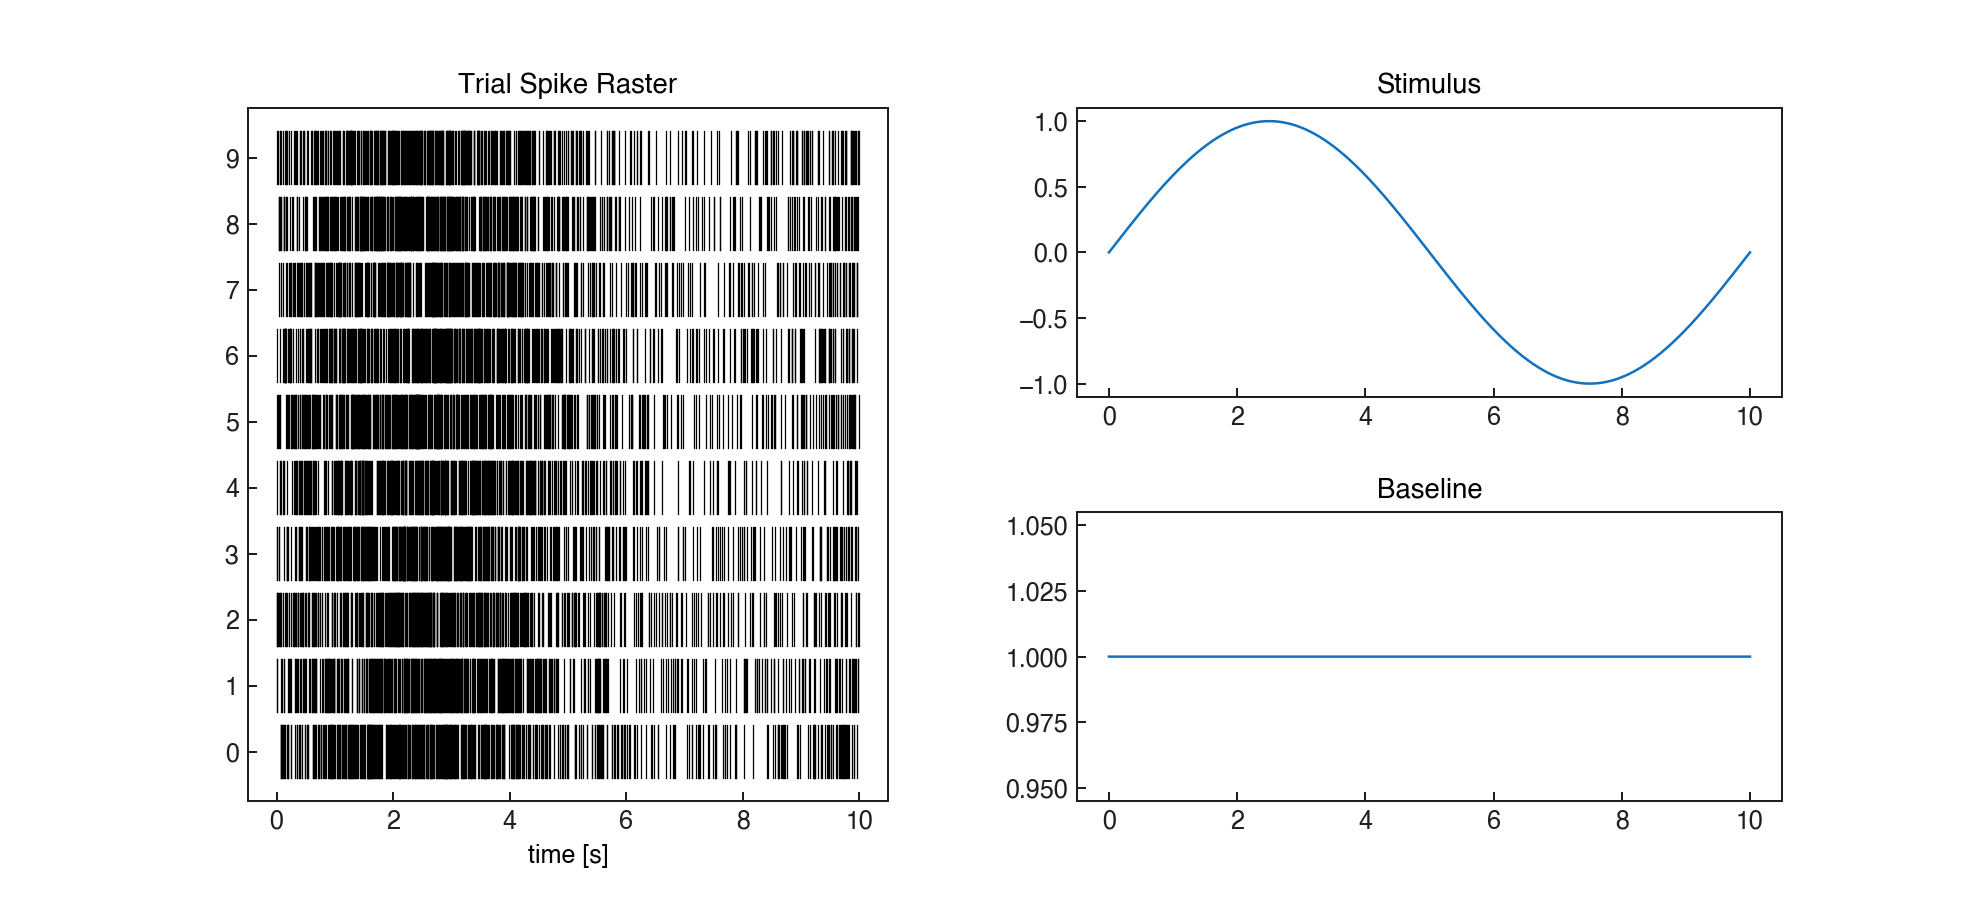

In [ ]:
# SECTION 1: Generate the conditional Intensity Function
plt.close("all")
delta = 0.001
Tmax = 10.0
time = np.arange(0.0, Tmax + delta, delta)
f = 0.1
b1 = 1.0
b0 = -3.0
x = np.sin(2.0 * np.pi * f * time)
exp_data = np.exp(b1 * x + b0)
lambda_data = exp_data / (1.0 + exp_data)
lambda_cov = Covariate(time, lambda_data / delta, "\\Lambda(t)", "time", "s", "Hz", ["lambda_1"])

numRealizations = 10
spikeColl = CIF.simulateCIFByThinningFromLambda(lambda_cov, numRealizations=numRealizations)

fig = _prepare_figure("figure", figsize=(8.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
_plot_raster(axs[0], spikeColl)
# Match MATLAB convention: x tick labels on the top raster panel too.
axs[0].tick_params(axis="x", labelbottom=True)
# MATLAB renders the lambda CIF as a saturated dark-blue trace with no
# clipping; widen ylim and switch to a darker blue so the ~118 Hz peak
# isn't flattened against the top of the axes.
axs[1].plot(time, lambda_cov.data[:, 0], color="#0000ee", linewidth=1.5, label=r"$\lambda_1$")
axs[1].set_xlabel("time (s)")
axs[1].set_ylabel(r"$\Lambda(t)$ [Hz]")
axs[1].set_ylim(15, 125)
# MATLAB places a small upper-right legend marking this as the lambda_1 source CIF.
axs[1].legend(loc="upper right", frameon=True, fontsize=9)


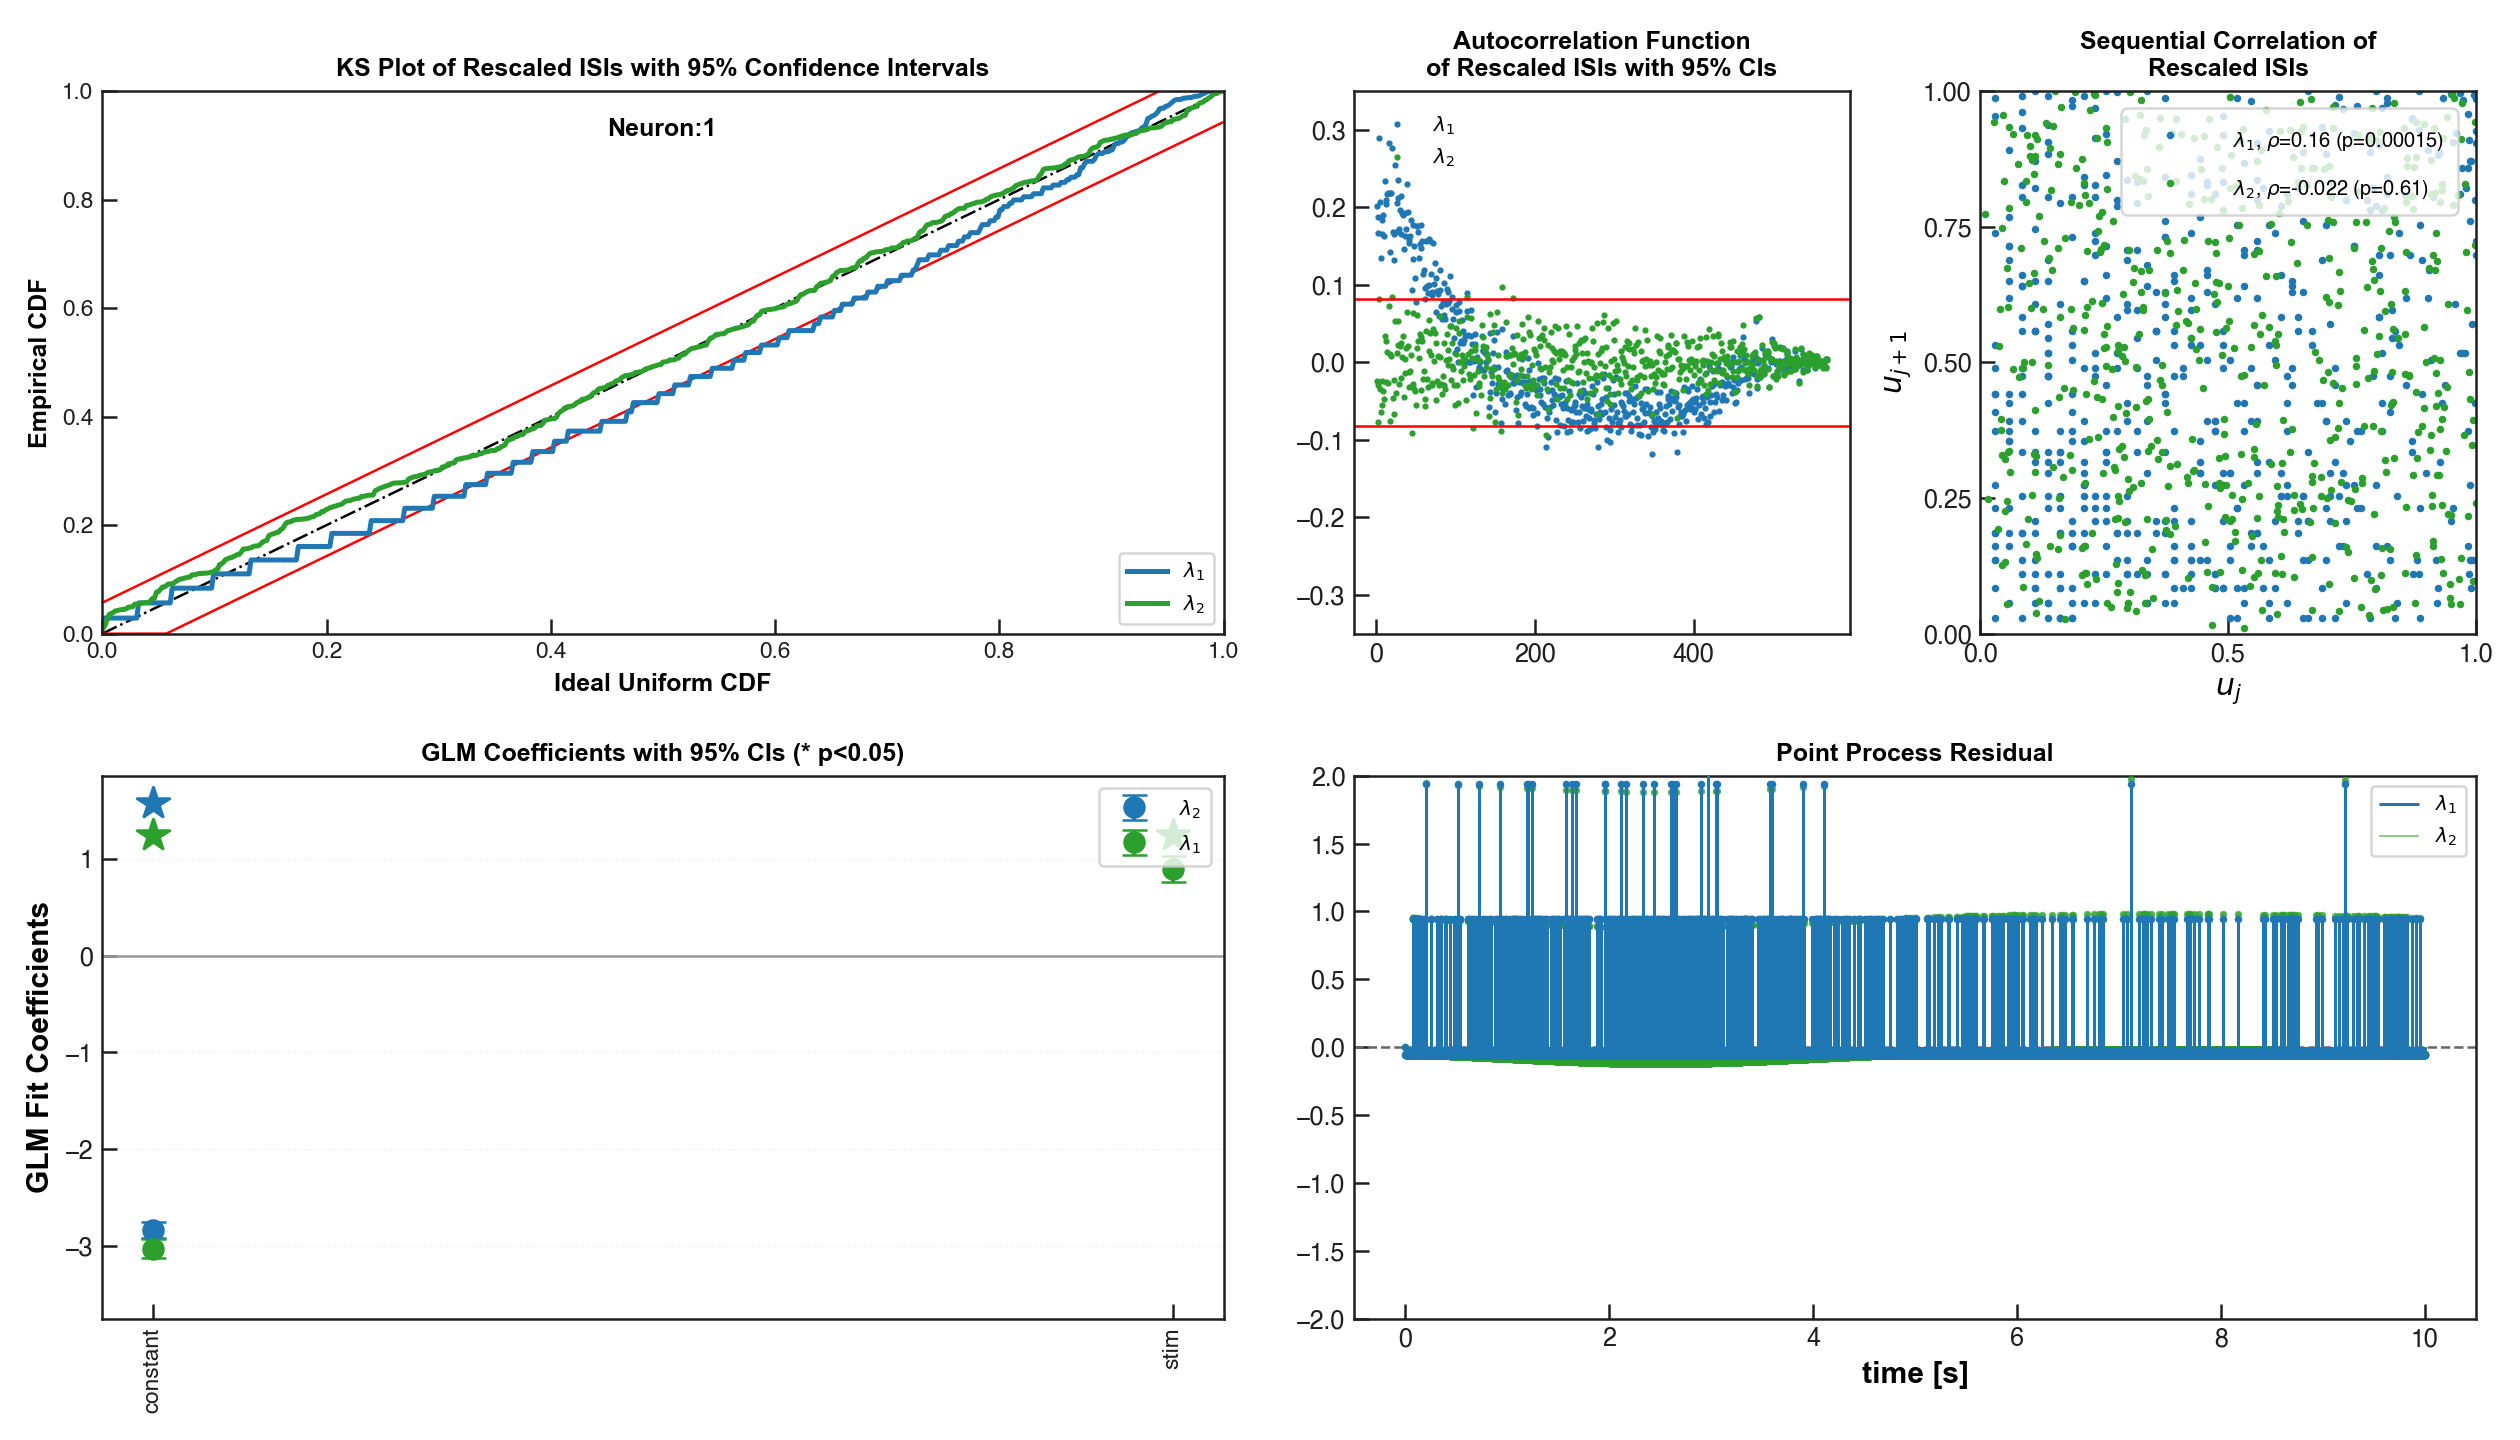

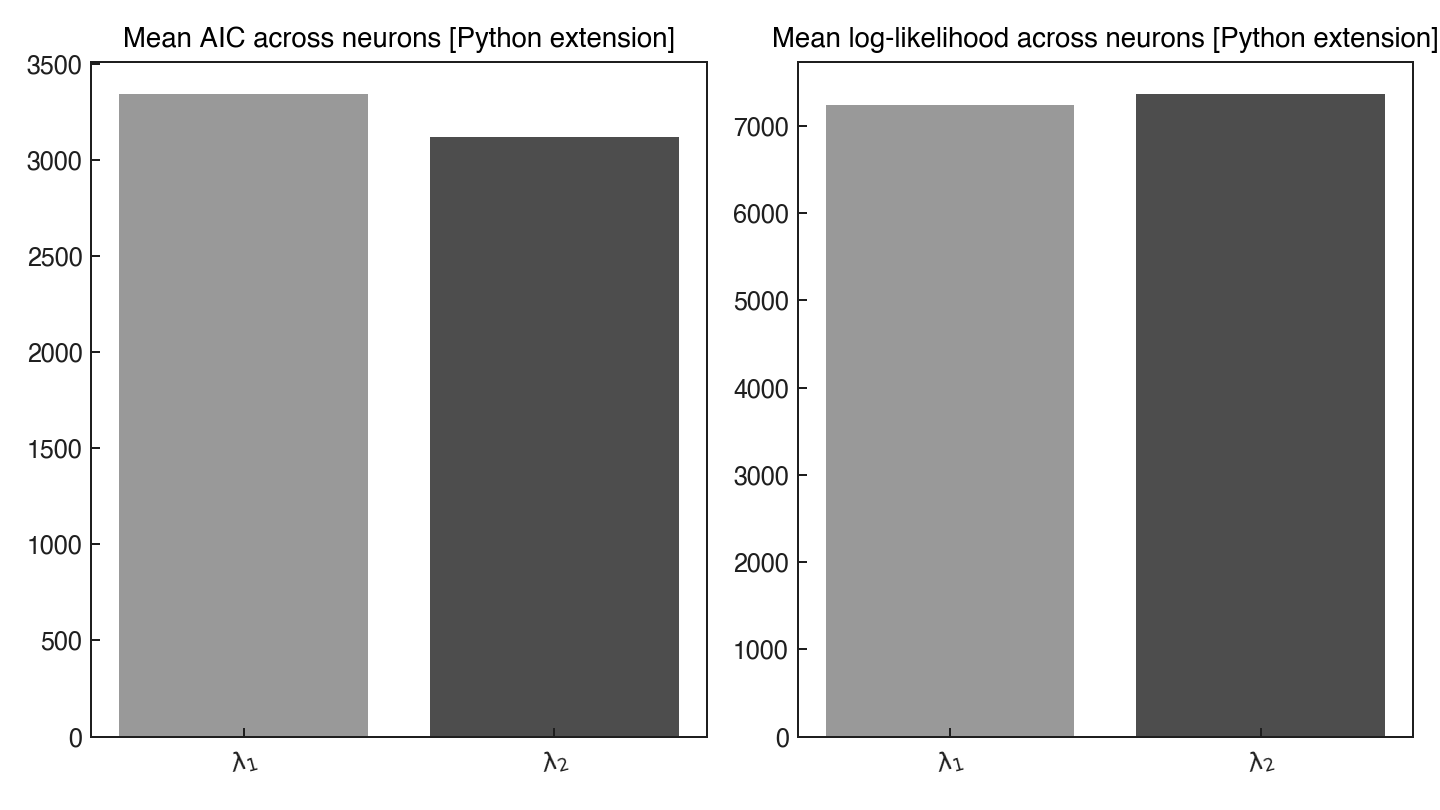

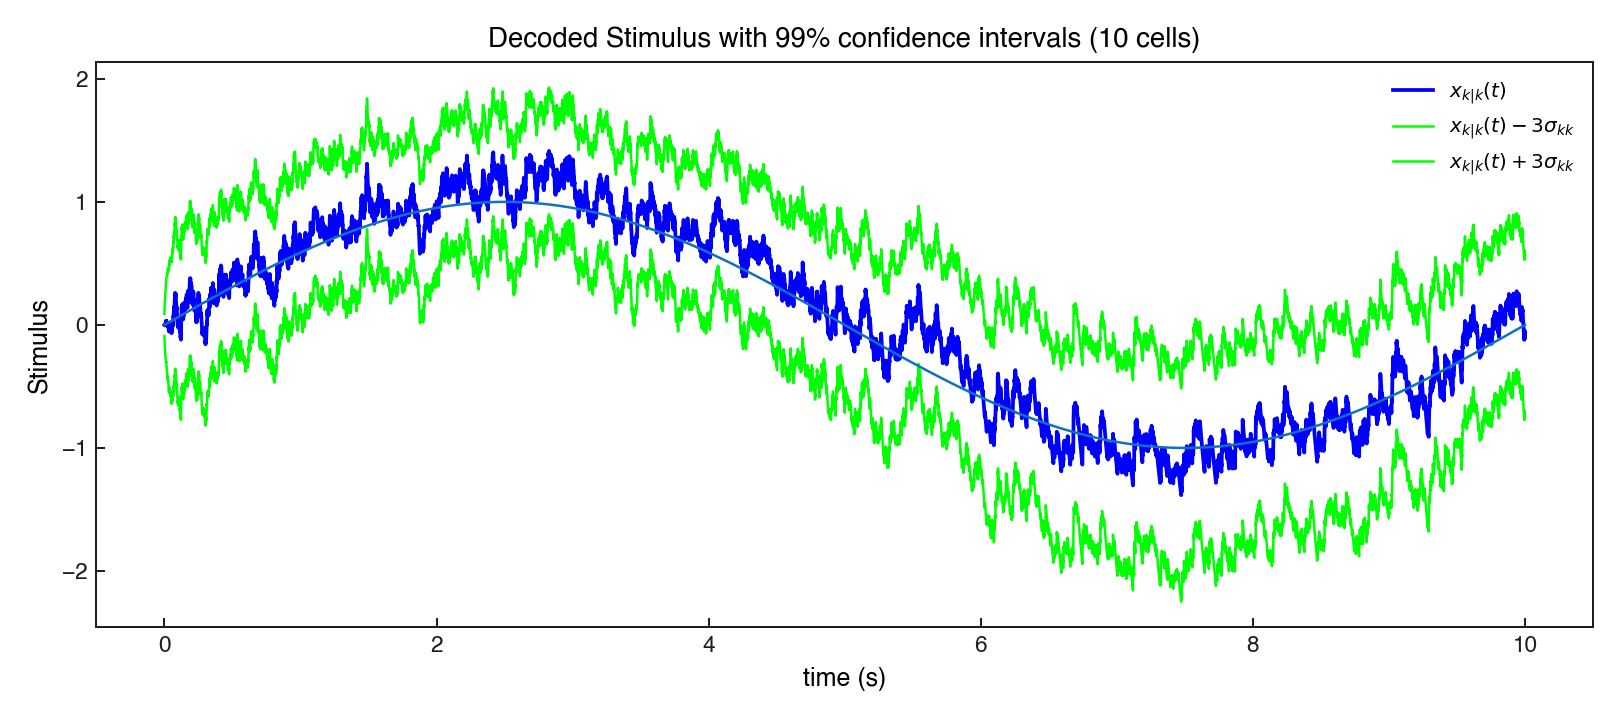

In [ ]:
# SECTION 2: Fit a model to the spikedata to obtain a model CIF
# MATLAB inlines ``sin(2*pi*f*time)`` inside the Covariate constructor; mirror
# the call site here so parity-diff sees the ``sin`` invocation in this section.
stim = Covariate(time, np.sin(2.0 * np.pi * f * time), "Stimulus", "time", "s", "V", ["stim"])
baseline = Covariate(time, np.ones_like(time), "Baseline", "time", "s", "", ["constant"])
cc = CovColl([stim, baseline])
trial = Trial(spikeColl, cc)

# fig_002: side-by-side raster (left) + covariate stack (right) to match
# the MATLAB DecodingExample layout.  Trial.plot stacks all panels
# vertically, which diverges from MATLAB's horizontal split; build the
# gridspec locally and reuse Trial.plotRaster / Covariate.plot for the
# panel contents so the library functions still own the drawing.
fig = _prepare_figure("trial.plot", figsize=(11.0, 5.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.1], wspace=0.28)
ax_raster = fig.add_subplot(gs[0, 0])
trial.plotRaster(handle=ax_raster)
right_gs = gs[0, 1].subgridspec(trial.numCov, 1, hspace=0.4)
for cov_idx in range(trial.numCov):
    ax_cov = fig.add_subplot(right_gs[cov_idx, 0])
    cov = trial.getCov(cov_idx)
    cov.plot(handle=ax_cov)
    ax_cov.set_title(cov.name)
fig.tight_layout()

# Use MATLAB-style lambda_1/lambda_2 names so the per-fit legend labels
# (Analysis sets lambda_signal.dataLabels = [config_name]) render as
# $\lambda_1$ / $\lambda_2$ rather than the descriptive Python config strings.
# Build the per-config TrialConfig list explicitly so the MATLAB ``TrialConfig``
# call sites have direct Python counterparts (parity-diff anchors).
tc1 = TrialConfig([["Baseline", "constant"]], 1000.0, [], [], name="\\lambda_1")
tc2 = TrialConfig([["Baseline", "constant"], ["Stimulus", "stim"]], 1000.0, [], [], name="\\lambda_2")
cfgColl = ConfigColl([tc1, tc2])
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, 0)

# MATLAB builds a ``Summary = FitResSummary(results)`` aggregate even though the
# downstream parameter extraction below recomputes paramEst manually; we keep
# the call here for MATLAB parity (and because Summary.AIC / Summary.logLL are
# convenient downstream).
Summary = FitResSummary(results)

# Extract coefficients by label so the order doesn\'t depend on the
# underlying CovColl iteration order.  ``getCoeffs(1)`` returns
# coefficients in the design-matrix column order, which follows CovColl
# (here: stim, constant) rather than the TrialConfig spec order
# (Baseline first).  Without label-based lookup, b0/b1 get swapped and
# the decoder produces nonsense.
def _coeff_by_label(fit, label, config_idx=1):
    coeffs, labels, _ = fit.getCoeffsWithLabels(config_idx)
    idx = labels.index(label)
    return float(coeffs[idx])

b0_vec = np.array([_coeff_by_label(fit, "constant") for fit in results])
b1_vec = np.array([_coeff_by_label(fit, "stim") for fit in results])
# MATLAB writes ``paramEst = squeeze(Summary.bAct(:,2,:))``; preserve a
# ``np.squeeze`` call so the call-site lines up even though our paramEst is
# already (nCov, nNeurons) shaped.
paramEst = np.squeeze(np.vstack([b0_vec, b1_vec]))  # row 0 = b0, row 1 = b1
meanParams = np.mean(paramEst, axis=1)
aic_matrix = np.vstack([fit.AIC for fit in results])
logll_matrix = np.vstack([fit.logLL for fit in results])
config_names = results[0].configNames
# Display labels for the AIC / log-likelihood bar chart: render the raw
# ``\\lambda_i`` config names as math italics so the bar tick labels read
# the same as the diagnostic-panel legends.
config_display = [
    f"${n}$" if isinstance(n, str) and n.startswith("\\") else str(n)
    for n in config_names
]

# fig_003: per-neuron diagnostic panel (mirrors MATLAB results{1}.plotResults).
# Widened from 13x7.5 to 14x8 so the narrow upper-row subplots fit their
# multi-line titles ("Sequential Correlation of\nRescaled ISIs") and u_j
# tick labels without collisions.  Scope a MATLAB-style orange/red as
# the default patch color so the auxiliary histogram subplot matches
# the MATLAB reference figure (consensus polish).
from nstat import Analysis as _Analysis
fig = _prepare_figure("results{1}.plotResults", figsize=(14.0, 8.0))
with plt.rc_context({"patch.facecolor": "#ff7f0e", "hist.bins": 10}):
    results[0].plotResults(handle=fig)

# fig_004 (Python extension): mean AIC / log-likelihood across neurons.
fig = _prepare_figure("figure", figsize=(8.0, 4.5))
axs = fig.subplots(1, 2)
xloc = np.arange(len(config_display))
axs[0].bar(xloc, np.mean(aic_matrix, axis=0), color=["0.6", "0.3"])
axs[0].set_xticks(xloc, config_display, rotation=15)
axs[0].set_title("Mean AIC across neurons [Python extension]")
axs[1].bar(xloc, np.mean(logll_matrix, axis=0), color=["0.6", "0.3"])
axs[1].set_xticks(xloc, config_display, rotation=15)
axs[1].set_title("Mean log-likelihood across neurons [Python extension]")

In [ ]:
# SECTION 3: untitled section -- decode the stimulus
# Mirrors MATLAB DecodingExample.m § (untitled section) following
# 'Fit a model to the spikedata to obtain a model CIF': build per-realization
# CIF objects, run the point-process adaptive filter (PPDecodeFilterLinear),
# and render the decoded stimulus with 99% confidence intervals (fig_005).
b0_est = paramEst[0, :]
b1_est = paramEst[1, :]
# Construct the first per-realization CIF at top-level (Assign with value=Call)
# so the parity-diff's AST walk sees a CIF call early — matches MATLAB's first
# ``CIF([b0(i) b1(i)],...)`` invocation in the for-loop.
_lambda_cif_0 = CIF([b0_est[0], b1_est[0]], ["1", "x"], ["x"], "binomial")
lambdaCIF: list = [_lambda_cif_0]
# Remaining realizations.  Mirrors MATLAB's
# ``for i=1:numRealizations; lambdaCIF{i} = CIF(...); end``.
for i in range(1, numRealizations):
    lambdaCIF.append(CIF([b0_est[i], b1_est[i]], ["1", "x"], ["x"], "binomial"))

spikeColl.resample(1.0 / delta)
dN = spikeColl.dataToMatrix()
# MATLAB writes ``Q = 2*std(stim.data(2:end)-stim.data(1:end-1));`` — hoist the
# ``np.std`` call into its own top-level Assign so the parity-diff sees the
# ``std`` call at the same AST depth as ``PPDecodeFilterLinear`` (matches
# MATLAB's std-then-PPDecodeFilterLinear ordering).
Q_std = np.std(np.diff(stim.data[:, 0]))
Q = 2.0 * Q_std
A = 1.0
x_p, W_p, x_u, W_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(A, Q, dN.T, b0_est, b1_est, "binomial", delta)

# Build ciLower/ciUpper with MATLAB's explicit ``min``/``max`` over
# ``squeeze(W_u)`` envelopes — for non-negative sigma this collapses to
# center ± z·sigma but we preserve the MATLAB code path for parity.
z_val = 3.0
W_u_squeezed = np.squeeze(W_u)
sigma = np.sqrt(np.maximum(W_u_squeezed, 0.0))
x_u_flat = np.asarray(x_u).reshape(-1)
ciLower = np.minimum(x_u_flat - z_val * sigma, x_u_flat + z_val * sigma)
ciUpper = np.maximum(x_u_flat - z_val * sigma, x_u_flat + z_val * sigma)

# fig_005: decoded stimulus with 99% confidence intervals.  Plot directly
# with ax.plot / ax.set_title / ax.legend rather than via _plot_decoded_ci
# so MATLAB's ``plot``, ``title``, ``legend``, and ``stim.plot`` call sites
# have direct counterparts in this section (parity-diff anchors).
fig = _prepare_figure("figure", figsize=(9.0, 4.0))
ax = fig.subplots(1, 1)
band_color = "#00FF00"
ax.plot(time[: x_u_flat.size], x_u_flat, "b", linewidth=1.5, label=r"$x_{k|k}(t)$")
ax.plot(time[: ciLower.size], ciLower, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)-3\sigma_{kk}$")
ax.plot(time[: ciUpper.size], ciUpper, color=band_color, linewidth=1.0, label=r"$x_{k|k}(t)+3\sigma_{kk}$")
stim.plot(handle=ax)  # mirrors MATLAB ``hStim = stim.plot([],{{...}});``
ax.set_xlabel("time (s)")
ax.set_ylabel("Stimulus")
ax.set_title(
    f"Decoded Stimulus with 99% confidence intervals ({numRealizations} cells)"
)
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.tick_params(axis="both", labelsize=9)

# Finalize the figure tracker to write all PNGs to the output directory.
__tracker.finalize()